# OMI Transactions Exploration

Exploratory data analysis and cleaning of OMI (Osservatorio del Mercato Immobiliare) real estate transaction data for Italian municipalities, covering the years **2011–2025**.

The focus is on the **NTN (Numero Transazioni Normalizzate / Number of Normalised Transactions)** indicator, broken down by:

- geography (region, province, municipality)
- property size class (residential, in square metre bands)
- property category (offices, shops, warehouses, agricultural, etc.)

**Goals of this notebook**

1. Load and harmonize the four OMI source files provided for each year.
2. Merge them into a single, tidy, long-format table (`transactions_df`) indexed by municipality and year.
3. Validate data quality: missing values, duplicate keys, internal consistency of the NTN figures, and stability of the geographical reference data over time.

**Output**: a cleaned `transactions_df` / `transactions_full` DataFrame ready for downstream analysis (see [Conclusions](#6.-Conclusions-and-next-steps) at the end of the notebook).

## 1. Setup

In [ ]:
from pathlib import Path
import re

import pandas as pd
import matplotlib.pyplot as plt

# =============================================================================
# CONFIGURATION
# =============================================================================

CWD = Path.cwd()
PROJECT_ROOT = CWD.parent

TRANSACTIONS_FOLDER = PROJECT_ROOT / "data" / "raw" / "transactions"

## 2. Import Data

The OMI transaction data are provided through **four files per reference year**, stored under `data/raw/transactions/<year>/`:

| File | Content |
|---|---|
| `lista-com` | municipality reference data (region, province, municipality name, code) |
| `valori-com` | non-residential transaction volumes by municipality |
| `valori-per` | transaction volumes at provincial level |
| `valori-res` | residential market transaction volumes, by size class |

`lista-com` acts as the "spine" of the dataset: every municipality it lists is later enriched with the residential, commercial, and provincial figures via a left join on the municipality code (`CodCom`).

In [105]:
YEAR_FOLDERS = sorted(
    folder
    for folder in TRANSACTIONS_FOLDER.iterdir()
    if folder.is_dir() and folder.name.isdigit()
)

for folder in YEAR_FOLDERS:
    print(folder.name)

2011
2012
2013
2014
2015
2016
2017
2018
2019
2020
2021
2022
2023
2024
2025


In [106]:
def get_transaction_files(year_folder: Path) -> dict[str, Path]:
    """Return the four OMI transaction files for a given year."""

    files = {
        file.name.lower(): file
        for file in year_folder.iterdir()
        if file.is_file()
    }

    return {
        "lista_com": next(
            file
            for name, file in files.items()
            if "lista-com" in name
        ),
        "valori_com": next(
            file
            for name, file in files.items()
            if "valori-com" in name
        ),
        "valori_per": next(
            file
            for name, file in files.items()
            if "valori-per" in name
        ),
        "valori_res": next(
            file
            for name, file in files.items()
            if "valori-res" in name
        ),
    }

for year_folder in YEAR_FOLDERS:
    print(f"\n{year_folder.name}")

    transaction_files = get_transaction_files(year_folder)

    for dataset, file in transaction_files.items():
        print(f"  {dataset}: {file.name}")


2011
  lista_com: 2011_LISTA-COM.csv
  valori_com: 2011_VALORI-COM.csv
  valori_per: 2011_VALORI-PER.csv
  valori_res: 2011_VALORI-RES.csv

2012
  lista_com: 2012_LISTA-COM.csv
  valori_com: 2012_VALORI-COM.csv
  valori_per: 2012_VALORI-PER.csv
  valori_res: 2012_VALORI-RES.csv

2013
  lista_com: 2013_LISTA-COM.csv
  valori_com: 2013_VALORI-COM.csv
  valori_per: 2013_VALORI-PER.csv
  valori_res: 2013_VALORI-RES.csv

2014
  lista_com: 2014_LISTA-COM.csv
  valori_com: 2014_VALORI-COM.csv
  valori_per: 2014_VALORI-PER.csv
  valori_res: 2014_VALORI-RES.csv

2015
  lista_com: 2015_LISTA-COM.csv
  valori_com: 2015_VALORI-COM.csv
  valori_per: 2015_VALORI-PER.csv
  valori_res: 2015_VALORI-RES.csv

2016
  lista_com: 2016_LISTA-COM.csv
  valori_com: 2016_VALORI-COM.csv
  valori_per: 2016_VALORI-PER.csv
  valori_res: 2016_VALORI-RES.csv

2017
  lista_com: 2017_LISTA-COM.csv
  valori_com: 2017_VALORI-COM.csv
  valori_per: 2017_VALORI-PER.csv
  valori_res: 2017_VALORI-RES.csv

2018
  lista_com: 2

In [107]:
lista_com = {}
valori_com = {}
valori_per = {}
valori_res = {}

for year_folder in YEAR_FOLDERS:

    year = int(year_folder.name)

    files = get_transaction_files(year_folder)

    lista_com[year] = pd.read_csv(
        files["lista_com"],
        sep=";",
        decimal=","
    )

    valori_com[year] = pd.read_csv(
        files["valori_com"],
        sep=";",
        decimal=","
    )

    valori_per[year] = pd.read_csv(
        files["valori_per"],
        sep=";",
        decimal=","
    )

    valori_res[year] = pd.read_csv(
        files["valori_res"],
        sep=";",
        decimal=","
    )

In [108]:
lista_com[2025].head()

,Area,Regione,Provincia,2025_CodCom,Comune,Cap,TAGLIA MERCATO
0,Nord Est,Veneto,PD,A001,ABANO TERME,NonCap,M
1,Nord Ovest,Lombardia,LO,A004,ABBADIA CERRETO,NonCap,S
2,Nord Ovest,Lombardia,LC,A005,ABBADIA LARIANA,NonCap,S
3,Centro,Toscana,SI,A006,ABBADIA SAN SALVATORE,NonCap,S
4,Isole,Sardegna,OR,A007,ABBASANTA,NonCap,S


In [109]:
valori_res[2018].head()

,AREA,Regione,prov,2018_CodCom,NTN fino a 50 mq,NTN 50 -| 85 mq,NTN 85 -| 115 mq,NTN 115 -| 145 mq,NTN oltre 145 mq,NTN 2018
0,Nord Est,Veneto,PD,A001,14.0,70.25,69.00,50.10,88.14,291.49
1,Nord Ovest,Lombardia,LO,A004,0.0,0.00,0.00,0.00,1.00,1.00
2,Nord Ovest,Lombardia,LC,A005,4.0,11.50,7.50,8.96,6.00,37.96
3,Centro,Toscana,SI,A006,6.0,26.75,24.75,24.50,9.25,91.25
4,Isole,Sardegna,OR,A007,0.0,4.00,1.00,0.00,7.00,12.00


Quick sanity check: every dataset should have been loaded for the same set of years.

In [110]:
print("lista-com:", sorted(lista_com))
print("valori-com:", sorted(valori_com))
print("valori-per:", sorted(valori_per))
print("valori-res:", sorted(valori_res))

lista-com: [2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025]
valori-com: [2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025]
valori-per: [2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025]
valori-res: [2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025]


In [111]:
assert set(lista_com) == set(valori_com)
assert set(lista_com) == set(valori_per)
assert set(lista_com) == set(valori_res)

## 3. Dataset Processing

### 3.1 Overview

Row counts per file and per year, as a first look at dataset size and completeness.

In [112]:
overview = []

for year in sorted(lista_com):

    overview.append(
        {
            "year": year,
            "lista_com_rows": len(lista_com[year]),
            "valori_com_rows": len(valori_com[year]),
            "valori_per_rows": len(valori_per[year]),
            "valori_res_rows": len(valori_res[year]),
        }
    )

overview = pd.DataFrame(overview)

overview

,year,lista_com_rows,valori_com_rows,valori_per_rows,valori_res_rows
0,2011,7715,7715,7715,7715
1,2012,7715,7715,7715,7715
2,2013,7698,7698,7698,7698
3,2014,7665,7665,7665,7665
4,2015,7661,7661,7661,7661
5,2016,7645,7645,7645,7645
6,2017,7624,7624,7624,7639
7,2018,7603,7603,7604,7603
8,2019,7564,7564,7564,7564
9,2020,7562,7562,7562,7562


### 3.2 Harmonize geographical column names

Column names for the municipality code (`CodCom`) and other geographical fields (`Area`, `Regione`, `Provincia`) are not always spelled consistently across years and files (e.g. `Prov` vs `Provincia`, `Cod_Com` vs `CodCom`). `get_codcom_column` first checks that each file has exactly one recognisable municipality-code column, then `normalize_columns` renames all geographical columns to a common convention so the files can be merged on `CodCom`.

In [113]:
def get_codcom_column(df: pd.DataFrame) -> str:
    """Return the municipality code column."""

    codcom_columns = [
        col
        for col in df.columns
        if "CodCom" in col
    ]

    if len(codcom_columns) != 1:
        raise ValueError(
            f"Expected exactly one CodCom column, "
            f"found: {codcom_columns}"
        )

    return codcom_columns[0]

for year in sorted(lista_com):

    key = get_codcom_column(lista_com[year])

    print(
        f"{year}: {key} | "
        f"unique={lista_com[year][key].nunique():,} | "
        f"duplicates={lista_com[year][key].duplicated().sum():,}"
    )

2011: 2011_CodCom | unique=7,715 | duplicates=0
2012: 2012_CodCom | unique=7,715 | duplicates=0
2013: 2013_CodCom | unique=7,698 | duplicates=0
2014: 2014_CodCom | unique=7,665 | duplicates=0
2015: 2015_CodCom | unique=7,661 | duplicates=0
2016: 2016_CodCom | unique=7,645 | duplicates=0
2017: 2017_CodCom | unique=7,624 | duplicates=0
2018: 2018_CodCom | unique=7,603 | duplicates=0
2019: 2019_CodCom | unique=7,564 | duplicates=0
2020: 2020_CodCom | unique=7,562 | duplicates=0
2021: 2021_CodCom | unique=7,563 | duplicates=0
2022: 2022_CodCom | unique=7,563 | duplicates=0
2023: 2023_CodCom | unique=7,563 | duplicates=0
2024: 2024_CodCom | unique=7,561 | duplicates=0
2025: 2025_CodCom | unique=7,560 | duplicates=0


In [114]:
def normalize_columns(df: pd.DataFrame) -> pd.DataFrame:
    """Normalize common geographical column names."""

    df = df.copy()

    rename_map = {}

    for column in df.columns:
        column_upper = column.upper()

        if column_upper == "AREA":
            rename_map[column] = "Area"

        elif column_upper == "REGIONE":
            rename_map[column] = "Regione"

        elif column_upper in {"PROV", "PROVINCIA"}:
            rename_map[column] = "Provincia"

        elif "CODCOM" in column_upper:
            rename_map[column] = "CodCom"

        elif "CODFITT" in column_upper:
            rename_map[column] = "CodCom"

        elif column_upper == "COD_COM":
            rename_map[column] = "CodCom"

    return df.rename(columns=rename_map)

for datasets in [
    lista_com,
    valori_com,
    valori_per,
    valori_res,
]:
    for year in datasets:
        datasets[year] = normalize_columns(
            datasets[year]
        )

In [115]:
for year in sorted(valori_res):
    print(
        year,
        [
            col
            for col in valori_res[year].columns
            if col in ["Area", "Regione", "Provincia", "CodCom"]
        ],
    )

2011 ['Area', 'Regione', 'Provincia', 'CodCom']
2012 ['Area', 'Regione', 'Provincia', 'CodCom']
2013 ['Area', 'Regione', 'Provincia', 'CodCom']
2014 ['Area', 'Regione', 'Provincia', 'CodCom']
2015 ['Area', 'Regione', 'Provincia', 'CodCom']
2016 ['Area', 'Regione', 'Provincia', 'CodCom']
2017 ['Area', 'Regione', 'Provincia', 'CodCom']
2018 ['Area', 'Regione', 'Provincia', 'CodCom']
2019 ['Area', 'Regione', 'Provincia', 'CodCom']
2020 ['Area', 'Regione', 'Provincia', 'CodCom']
2021 ['Area', 'Regione', 'Provincia', 'CodCom']
2022 ['Area', 'Regione', 'Provincia', 'CodCom']
2023 ['Area', 'Regione', 'Provincia', 'CodCom']
2024 ['Area', 'Regione', 'Provincia', 'CodCom']
2025 ['Area', 'Regione', 'Provincia', 'CodCom']


In [116]:
for year in sorted(lista_com):

    print(
        year,
        lista_com[year]["CodCom"].nunique(),
        valori_res[year]["CodCom"].nunique(),
        valori_com[year]["CodCom"].nunique(),
        valori_per[year]["CodCom"].nunique(),
    )

2011 7715 7715 7715 7715
2012 7715 7715 7715 7715
2013 7698 7698 7698 7698
2014 7665 7665 7665 7665
2015 7661 7661 7661 7661
2016 7645 7645 7645 7645
2017 7624 7626 7624 7624
2018 7603 7603 7603 7603
2019 7564 7564 7564 7564
2020 7562 7562 7562 7562
2021 7563 7563 7563 7563
2022 7563 7563 7563 7563
2023 7563 7563 7563 7563
2024 7561 7561 7561 7561
2025 7560 7560 7560 7560


### 3.3 Handle non-standard `CodCom` values in `valori-res`

`valori-res` contains a few rows keyed by placeholder strings (e.g. `"non nati"` / `"non nato"`, used by the source to aggregate transactions not attributable to a specific municipality) instead of a real municipality code. These show up as duplicated `CodCom` values and must be filtered out before merging, since the merge key is expected to uniquely identify a municipality.

In [117]:
for year in sorted(valori_res):

    print(
        year,
        valori_res[year].columns.tolist()
    )

2011 ['Area', 'Regione', 'Provincia', 'CodCom', 'NTN 2011 fino a 50 mq', 'NTN 2011  50 -| 85 mq', 'NTN 2011  85 -| 115 mq', 'NTN 2011 115 -| 145 mq', 'NTN 2011 oltre 145 mq', 'NTN 2011']
2012 ['Area', 'Regione', 'Provincia', 'CodCom', 'NTN 2012 fino a 50 mq', 'NTN 2012 50 -| 85 mq', 'NTN 2012 85 -| 115 mq', 'NTN 2012 115 -| 145 mq', 'NTN 2012  oltre 145 mq', 'NTN 2012']
2013 ['Area', 'Regione', 'Provincia', 'CodCom', 'NTN 2013 fino a 50 mq', 'NTN 2013 50 -| 85 mq', 'NTN 2013 85 -| 115 mq', 'NTN 2013 115 -| 145 mq', 'NTN 2013 oltre 145 mq', 'NTN 2013']
2014 ['Area', 'Regione', 'Provincia', 'CodCom', 'NTN 2014 fino a 50 mq', 'NTN 2014 50 -| 85 mq', 'NTN 2014 85 -| 115 mq', 'NTN 2014 115 -| 145 mq', 'NTN 2014 oltre 145', 'NTN 2014']
2015 ['Area', 'Regione', 'Provincia', 'CodCom', 'NTN 2015 fino a 50 mq', 'NTN 2015 50 -| 85 mq', 'NTN 2015  85 -| 115 mq', 'NTN 2015 115 -| 145 mq', 'NTN 2015  oltre 145 mq', 'NTN 2015_TOTALE']
2016 ['Area', 'Regione', 'Provincia', 'CodCom', 'NTN 2016 fino a 5

In [118]:
for year in sorted(valori_res):

    duplicates = valori_res[year]["CodCom"].duplicated().sum()

    if duplicates > 0:
        print(
            f"{year}: {duplicates} duplicated CodCom"
        )

2017: 13 duplicated CodCom


In [119]:
for year in sorted(valori_res):

    mask = valori_res[year]["CodCom"].duplicated(
        keep=False
    )

    if mask.any():
        print(f"\n--- {year} ---")
        display(
            valori_res[year].loc[mask].head(20)
        )


--- 2017 ---


,Area,Regione,Provincia,CodCom,NTN 2017 fino a 50 mq,NTN 2017 50 -| 85 mq,NTN 2017 85 -| 115 mq,NTN 2017 115 -| 145 mq,NTN 2017 oltre 145 mq,NTN 2017
7624,Nord Ovest,Liguria,IM,non nati,0.0,0.0,0.0,0.0,0.0,0.0
7625,Nord Ovest,Piemonte,AL,non nati,0.0,0.0,0.0,0.0,0.0,0.0
7626,Centro,Toscana,LI,non nati,0.0,0.0,0.0,0.0,0.0,0.0
7627,Centro,Toscana,AR,non nati,0.0,0.0,0.0,0.0,0.0,0.0
7628,Nord Ovest,Lombardia,CO,non nati,0.0,0.0,0.0,0.0,0.0,0.0
7629,Nord Ovest,Lombardia,LC,non nati,0.0,0.0,0.0,0.0,0.0,0.0
7630,Nord Ovest,Lombardia,MN,non nati,0.0,0.0,0.0,0.0,0.0,0.0
7631,Nord Est,Friuli- Venezia Giulia,UD,non nati,0.0,0.0,0.0,0.0,0.0,0.0
7632,Nord Est,Veneto,PD,non nati,0.0,0.0,0.0,0.0,0.0,0.0
7633,Sud,Calabria,CS,non nati,0.0,0.0,0.0,0.0,0.0,0.0


In [120]:
for year in sorted(valori_res):

    duplicates = (
        valori_res[year]
        .loc[
            valori_res[year]["CodCom"].duplicated(
                keep=False
            )
        ]
        ["CodCom"]
        .value_counts()
    )

    if not duplicates.empty:
        print(f"\n{year}")
        print(duplicates)


2017
CodCom
non nati    10
non nato     5
Name: count, dtype: int64


In [121]:
valori_res_clean = {}

for year, df in valori_res.items():

    valori_res_clean[year] = df.loc[
        ~df["CodCom"].isin(["non nati", "non nato"])
    ].copy()

In [122]:
for name, datasets in {
    "lista_com": lista_com,
    "valori_res": valori_res,
    "valori_com": valori_com,
    "valori_per": valori_per,
}.items():

    print(f"\n{name}")

    for year, df in sorted(datasets.items()):

        duplicates = df["CodCom"].duplicated().sum()

        if duplicates > 0:
            print(
                f"{year}: "
                f"{duplicates} duplicated CodCom"
            )


lista_com

valori_res
2017: 13 duplicated CodCom

valori_com

valori_per


### 3.4 Merge the four sources

For each year, `lista_com` (one row per municipality) is left-joined with the cleaned residential, non-residential and provincial datasets on `CodCom`. `validate="one_to_one"` enforces that the merge keys are unique on both sides, and the assertions below confirm that the merge did not create or drop any rows.

In [123]:
transactions = {}

for year in sorted(lista_com):

    transactions[year] = (
        lista_com[year]
        .merge(
            valori_res_clean[year],
            on="CodCom",
            how="left",
            suffixes=("", "_res"),
            validate="one_to_one",
        )
        .merge(
            valori_com[year],
            on="CodCom",
            how="left",
            suffixes=("", "_com"),
            validate="one_to_one",
        )
        .merge(
            valori_per[year],
            on="CodCom",
            how="left",
            suffixes=("", "_per"),
            validate="one_to_one",
        )
    )

for year, df in transactions.items():

    assert len(df) == len(lista_com[year])

    assert df["CodCom"].duplicated().sum() == 0

print("Merge completed successfully.")

Merge completed successfully.


In [124]:
for year in transactions:

    transactions[year]["reference_date"] = (
        pd.Timestamp(year=year, month=12, day=31)
    )

### 3.5 Normalize transaction (NTN) column names across years

The merge introduces duplicated geographical columns (suffixed `_res`, `_com`, `_per`) which are redundant with the ones already present from `lista_com`. NTN column names also vary by year (e.g. `NTN 2015_TOTALE` vs `NTN2020` vs `NTN`) and by property category. The cells below inspect the raw column names before cleanup, then apply `clean_transaction_columns` to drop the redundant geographical duplicates, and `normalize_transaction_columns` to map every NTN-related column onto a single, year-independent naming convention.

In [125]:
transactions[2025].columns.tolist()

['Area',
 'Regione',
 'Provincia',
 'CodCom',
 'Comune',
 'Cap',
 'TAGLIA MERCATO',
 'Area_res',
 'Regione_res',
 'Provincia_res',
 'NTN 2025 fino a 50 mq',
 'NTN 2025 50 -| 85 mq',
 'NTN 2025 85 -| 115 mq',
 'NTN 2025 115 -| 145 mq',
 'NTN 2025 oltre 145 mq',
 'NTN_2025',
 'Area_com',
 'Regione_com',
 'Provincia_com',
 'NTN_2025_Uffici',
 'NTN_2025_Negozi_Lab',
 'NTN_2025_Depositi_Comm_Autorimesse',
 'NTN_2025_TCO_B04',
 'NTN_2025_TCO_D02',
 'NTN_2025_TCO_D05',
 'NTN_2025_TCO_D08',
 'NTN_2025_PRO',
 'NTN_2025_AGR',
 'Area_per',
 'Regione_per',
 'Provincia_per',
 'NTN_2025_Depositi_Pert',
 'NTN_2025_Box',
 'reference_date']

In [126]:
transactions[2011].columns.tolist()

['Area',
 'Regione',
 'Provincia',
 'CodCom',
 'Comune',
 'Area_res',
 'Regione_res',
 'Provincia_res',
 'NTN 2011 fino a 50 mq',
 'NTN 2011  50 -| 85 mq',
 'NTN 2011  85 -| 115 mq',
 'NTN 2011 115 -| 145 mq',
 'NTN 2011 oltre 145 mq',
 'NTN 2011',
 'Area_com',
 'Regione_com',
 'Provincia_com',
 'NTN_2011_Uffici',
 'NTN_2011_Negozi_Lab',
 'NTN_2011_Depositi_Comm',
 'NTN_2011_TCO_B04',
 'NTN_2011_TCO_D02',
 'NTN_2011_TCO_D05',
 'NTN_2011_TCO_D08',
 'NTN_2011_PRO',
 'NTN_2011_AGR',
 'Area_per',
 'Regione_per',
 'Provincia_per',
 'NTN_2011_Box',
 'NTN_2011_Depositi_Pert',
 'reference_date']

In [127]:
for year in sorted(transactions):

    duplicated_columns = [
        col
        for col in transactions[year].columns
        if col.endswith(("_com", "_per", "_res"))
    ]

    if duplicated_columns:
        print(f"\n{year}:")
        print(duplicated_columns)


2011:
['Area_res', 'Regione_res', 'Provincia_res', 'Area_com', 'Regione_com', 'Provincia_com', 'Area_per', 'Regione_per', 'Provincia_per']

2012:
['Area_res', 'Regione_res', 'Provincia_res', 'Area_com', 'Regione_com', 'Provincia_com', 'Area_per', 'Regione_per', 'Provincia_per']

2013:
['Area_res', 'Regione_res', 'Provincia_res', 'Area_com', 'Regione_com', 'Provincia_com', 'Area_per', 'Regione_per', 'Provincia_per']

2014:
['Area_res', 'Regione_res', 'Provincia_res', 'Area_com', 'Regione_com', 'Provincia_com', 'Area_per', 'Regione_per', 'Provincia_per']

2015:
['Area_res', 'Regione_res', 'Provincia_res', 'Area_com', 'Regione_com', 'Provincia_com', 'Area_per', 'Regione_per', 'Provincia_per']

2016:
['Area_res', 'Regione_res', 'Provincia_res', 'Area_com', 'Regione_com', 'Provincia_com', 'Area_per', 'Regione_per', 'Provincia_per']

2017:
['Area_res', 'Regione_res', 'Provincia_res', 'Area_com', 'Regione_com', 'Provincia_com', 'Area_per', 'Regione_per', 'Provincia_per']

2018:
['Area_res', 

In [128]:
def clean_transaction_columns(
    df: pd.DataFrame,
) -> pd.DataFrame:
    """Remove duplicated geographical columns after merge."""

    df = df.copy()

    columns_to_drop = [
        "Area_res",
        "Regione_res",
        "Provincia_res",
        "Area_com",
        "Regione_com",
        "Provincia_com",
        "Area_per",
        "Regione_per",
        "Provincia_per",
    ]

    df = df.drop(
        columns=columns_to_drop,
        errors="ignore",
    )

    return df

for year in transactions:

    transactions[year] = clean_transaction_columns(
        transactions[year]
    )

In [129]:
transactions[2025].columns.tolist()

['Area',
 'Regione',
 'Provincia',
 'CodCom',
 'Comune',
 'Cap',
 'TAGLIA MERCATO',
 'NTN 2025 fino a 50 mq',
 'NTN 2025 50 -| 85 mq',
 'NTN 2025 85 -| 115 mq',
 'NTN 2025 115 -| 145 mq',
 'NTN 2025 oltre 145 mq',
 'NTN_2025',
 'NTN_2025_Uffici',
 'NTN_2025_Negozi_Lab',
 'NTN_2025_Depositi_Comm_Autorimesse',
 'NTN_2025_TCO_B04',
 'NTN_2025_TCO_D02',
 'NTN_2025_TCO_D05',
 'NTN_2025_TCO_D08',
 'NTN_2025_PRO',
 'NTN_2025_AGR',
 'NTN_2025_Depositi_Pert',
 'NTN_2025_Box',
 'reference_date']

In [130]:
for year in sorted(transactions):

    ntn_columns = [
        col
        for col in transactions[year].columns
        if "NTN" in col.upper()
    ]

    print(f"\n{year}:")
    print(ntn_columns)


2011:
['NTN 2011 fino a 50 mq', 'NTN 2011  50 -| 85 mq', 'NTN 2011  85 -| 115 mq', 'NTN 2011 115 -| 145 mq', 'NTN 2011 oltre 145 mq', 'NTN 2011', 'NTN_2011_Uffici', 'NTN_2011_Negozi_Lab', 'NTN_2011_Depositi_Comm', 'NTN_2011_TCO_B04', 'NTN_2011_TCO_D02', 'NTN_2011_TCO_D05', 'NTN_2011_TCO_D08', 'NTN_2011_PRO', 'NTN_2011_AGR', 'NTN_2011_Box', 'NTN_2011_Depositi_Pert']

2012:
['NTN 2012 fino a 50 mq', 'NTN 2012 50 -| 85 mq', 'NTN 2012 85 -| 115 mq', 'NTN 2012 115 -| 145 mq', 'NTN 2012  oltre 145 mq', 'NTN 2012', 'NTN_2012_Uffici', 'NTN_2012_Negozi_Lab', 'NTN_2012_Depositi_Comm', 'NTN_2012_TCO_B04', 'NTN_2012_TCO_D02', 'NTN_2012_TCO_D05', 'NTN_2012_TCO_D08', 'NTN_2012_PRO', 'NTN_2012_AGR', 'NTN_2012_Box', 'NTN_2012_Depositi_Pert']

2013:
['NTN 2013 fino a 50 mq', 'NTN 2013 50 -| 85 mq', 'NTN 2013 85 -| 115 mq', 'NTN 2013 115 -| 145 mq', 'NTN 2013 oltre 145 mq', 'NTN 2013', 'NTN_2013_Uffici', 'NTN_2013_Negozi_Lab', 'NTN_2013_Depositi_Comm', 'NTN_2013_TCO_B04', 'NTN_2013_TCO_D02', 'NTN_2013_

In [131]:
def normalize_transaction_columns(
    df: pd.DataFrame,
) -> pd.DataFrame:
    """Normalize NTN column names across years."""

    df = df.copy()

    rename_map = {}

    for column in df.columns:

        col = (
            column
            .strip()
            .lower()
            .replace(" ", "")
        )

        # Remove year from column name
        col = re.sub(r"ntn[_]?\d{4}", "ntn", col)

        # ---------------------------------------------------------
        # Residential NTN by surface class
        # ---------------------------------------------------------

        if "finoa50mq" in col or "finoa50_mq" in col:
            rename_map[column] = "NTN_0_50"

        elif "50-|85mq" in col:
            rename_map[column] = "NTN_50_85"

        elif "85-|115mq" in col:
            rename_map[column] = "NTN_85_115"

        elif "115-|145mq" in col:
            rename_map[column] = "NTN_115_145"

        elif "oltre145" in col:
            rename_map[column] = "NTN_145_PLUS"

        # ---------------------------------------------------------
        # Total residential NTN
        # ---------------------------------------------------------

        elif col in {"ntn", "ntntotale"}:
            rename_map[column] = "NTN"

        # ---------------------------------------------------------
        # Other property categories
        # ---------------------------------------------------------

        elif "uffici" in col:
            rename_map[column] = "NTN_UFFICI"

        elif "negozi_lab" in col or "negozilab" in col:
            rename_map[column] = "NTN_NEGOZI_LAB"

        elif "depositi_comm" in col:
            rename_map[column] = "NTN_DEPOSITI_COMM"

        elif "tco_b04" in col:
            rename_map[column] = "NTN_TCO_B04"

        elif "tco_d02" in col:
            rename_map[column] = "NTN_TCO_D02"

        elif "tco_d05" in col:
            rename_map[column] = "NTN_TCO_D05"

        elif "tco_d08" in col:
            rename_map[column] = "NTN_TCO_D08"

        elif col.endswith("pro"):
            rename_map[column] = "NTN_PRO"

        elif col.endswith("agr"):
            rename_map[column] = "NTN_AGR"

        elif "box" in col:
            rename_map[column] = "NTN_BOX"

        elif "depositi_pert" in col:
            rename_map[column] = "NTN_DEPOSITI_PERT"

    return df.rename(columns=rename_map)

for year in transactions:

    transactions[year] = normalize_transaction_columns(
        transactions[year]
    )

for year in sorted(transactions):

    ntn_columns = [
        col
        for col in transactions[year].columns
        if col.startswith("NTN")
    ]

    print(f"\n{year}:")
    print(ntn_columns)


2011:
['NTN_0_50', 'NTN_50_85', 'NTN_85_115', 'NTN_115_145', 'NTN_145_PLUS', 'NTN', 'NTN_UFFICI', 'NTN_NEGOZI_LAB', 'NTN_DEPOSITI_COMM', 'NTN_TCO_B04', 'NTN_TCO_D02', 'NTN_TCO_D05', 'NTN_TCO_D08', 'NTN_PRO', 'NTN_AGR', 'NTN_BOX', 'NTN_DEPOSITI_PERT']

2012:
['NTN_0_50', 'NTN_50_85', 'NTN_85_115', 'NTN_115_145', 'NTN_145_PLUS', 'NTN', 'NTN_UFFICI', 'NTN_NEGOZI_LAB', 'NTN_DEPOSITI_COMM', 'NTN_TCO_B04', 'NTN_TCO_D02', 'NTN_TCO_D05', 'NTN_TCO_D08', 'NTN_PRO', 'NTN_AGR', 'NTN_BOX', 'NTN_DEPOSITI_PERT']

2013:
['NTN_0_50', 'NTN_50_85', 'NTN_85_115', 'NTN_115_145', 'NTN_145_PLUS', 'NTN', 'NTN_UFFICI', 'NTN_NEGOZI_LAB', 'NTN_DEPOSITI_COMM', 'NTN_TCO_B04', 'NTN_TCO_D02', 'NTN_TCO_D05', 'NTN_TCO_D08', 'NTN_PRO', 'NTN_AGR', 'NTN_BOX', 'NTN_DEPOSITI_PERT']

2014:
['NTN_0_50', 'NTN_50_85', 'NTN_85_115', 'NTN_115_145', 'NTN_145_PLUS', 'NTN', 'NTN_UFFICI', 'NTN_NEGOZI_LAB', 'NTN_DEPOSITI_COMM', 'NTN_TCO_B04', 'NTN_TCO_D02', 'NTN_TCO_D05', 'NTN_TCO_D08', 'NTN_PRO', 'NTN_AGR', 'NTN_BOX', 'NTN_DEPOSITI

In [132]:
expected_ntn_columns = {
    "NTN_0_50",
    "NTN_50_85",
    "NTN_85_115",
    "NTN_115_145",
    "NTN_145_PLUS",
    "NTN",
    "NTN_UFFICI",
    "NTN_NEGOZI_LAB",
    "NTN_DEPOSITI_COMM",
    "NTN_TCO_B04",
    "NTN_TCO_D02",
    "NTN_TCO_D05",
    "NTN_TCO_D08",
    "NTN_PRO",
    "NTN_AGR",
    "NTN_BOX",
    "NTN_DEPOSITI_PERT",
}

for year, df in sorted(transactions.items()):

    actual = {
        col
        for col in df.columns
        if col.startswith("NTN")
    }

    missing = expected_ntn_columns - actual
    extra = actual - expected_ntn_columns

    if missing or extra:
        print(f"\n{year}")
        print("Missing:", missing)
        print("Extra:", extra)


2015
Missing: {'NTN'}
Extra: {'NTN 2015_TOTALE'}

2016
Missing: {'NTN'}
Extra: {'NTN 2016_TOTALE'}


In [133]:
for year, df in transactions.items():

    duplicated = df.columns[
        df.columns.duplicated()
    ]

    if len(duplicated) > 0:
        print(
            year,
            duplicated.tolist()
        )

In [134]:
for year, df in transactions.items():

    print(
        f"{year}: "
        f"rows={len(df):,} | "
        f"unique CodCom={df['CodCom'].nunique():,} | "
        f"duplicates={df['CodCom'].duplicated().sum():,}"
    )

2011: rows=7,715 | unique CodCom=7,715 | duplicates=0
2012: rows=7,715 | unique CodCom=7,715 | duplicates=0
2013: rows=7,698 | unique CodCom=7,698 | duplicates=0
2014: rows=7,665 | unique CodCom=7,665 | duplicates=0
2015: rows=7,661 | unique CodCom=7,661 | duplicates=0
2016: rows=7,645 | unique CodCom=7,645 | duplicates=0
2017: rows=7,624 | unique CodCom=7,624 | duplicates=0
2018: rows=7,603 | unique CodCom=7,603 | duplicates=0
2019: rows=7,564 | unique CodCom=7,564 | duplicates=0
2020: rows=7,562 | unique CodCom=7,562 | duplicates=0
2021: rows=7,563 | unique CodCom=7,563 | duplicates=0
2022: rows=7,563 | unique CodCom=7,563 | duplicates=0
2023: rows=7,563 | unique CodCom=7,563 | duplicates=0
2024: rows=7,561 | unique CodCom=7,561 | duplicates=0
2025: rows=7,560 | unique CodCom=7,560 | duplicates=0


### 3.6 Concatenate all years into a single long-format table

In [135]:
transactions_df = pd.concat(
    transactions.values(),
    ignore_index=True,
)

In [136]:
transactions_df.shape

(114262, 31)

In [137]:
transactions_df.head()

,Area,Regione,Provincia,CodCom,Comune,NTN_0_50,NTN_50_85,NTN_85_115,NTN_115_145,NTN_145_PLUS,...,NTN_DEPOSITI_PERT,reference_date,NTN 2015_TOTALE,NTN 2016_TOTALE,COD_ISTAT,Unnamed: 13,Unnamed: 14,Cod_Istat,Cap,TAGLIA MERCATO
0,Nord Ovest,Liguria,GE,A388,ARENZANO,21.83,78.94,41.78,21.37,11.00,...,28.19,2011-12-31,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Nord Ovest,Liguria,GE,A506,AVEGNO,0.00,8.00,11.51,7.50,3.00,...,13.76,2011-12-31,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Nord Ovest,Liguria,GE,A658,BARGAGLI,1.00,20.50,16.00,9.00,6.75,...,11.50,2011-12-31,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Nord Ovest,Liguria,GE,A922,BOGLIASCO,2.00,19.73,17.13,2.17,5.00,...,11.17,2011-12-31,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Nord Ovest,Liguria,GE,B067,BORZONASCA,3.00,6.52,5.75,5.50,5.50,...,5.50,2011-12-31,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [138]:
transactions_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 114262 entries, 0 to 114261
Data columns (total 31 columns):
 #   Column             Non-Null Count   Dtype         
---  ------             --------------   -----         
 0   Area               114262 non-null  str           
 1   Regione            114262 non-null  str           
 2   Provincia          112882 non-null  str           
 3   CodCom             114262 non-null  str           
 4   Comune             114262 non-null  str           
 5   NTN_0_50           114262 non-null  float64       
 6   NTN_50_85          114262 non-null  float64       
 7   NTN_85_115         114262 non-null  float64       
 8   NTN_115_145        114262 non-null  float64       
 9   NTN_145_PLUS       114262 non-null  float64       
 10  NTN                98956 non-null   float64       
 11  NTN_UFFICI         114262 non-null  float64       
 12  NTN_NEGOZI_LAB     114262 non-null  float64       
 13  NTN_DEPOSITI_COMM  114262 non-null  float64       
 14 

In [139]:
transactions_df["reference_date"].min(), transactions_df["reference_date"].max()

(Timestamp('2011-12-31 00:00:00'), Timestamp('2025-12-31 00:00:00'))

In [140]:
transactions_df["reference_date"].dt.year.value_counts().sort_index()

reference_date
2011    7715
2012    7715
2013    7698
2014    7665
2015    7661
2016    7645
2017    7624
2018    7603
2019    7564
2020    7562
2021    7563
2022    7563
2023    7563
2024    7561
2025    7560
Name: count, dtype: int64

In [141]:
transactions_df.duplicated(
    subset=["CodCom", "reference_date"]
).sum()

np.int64(0)

In [142]:
transactions_df["NTN"].value_counts().head(20)

NTN
2.0     2190
3.0     2131
4.0     2048
1.0     2034
5.0     1736
6.0     1618
0.0     1427
7.0     1418
8.0     1179
9.0     1000
10.0     934
11.0     857
12.0     746
13.0     669
14.0     592
15.0     511
4.5      487
16.0     467
6.5      462
8.5      459
Name: count, dtype: int64

## 4. Data quality & validation

### 4.1 Missing values overview

A small number of columns (leftover unnamed columns from the raw CSVs) are entirely artifacts of parsing and can be dropped outright.

In [143]:
missing_summary = (
    transactions_df.isna()
    .sum()
    .to_frame("missing")
)

missing_summary["missing_pct"] = (
    missing_summary["missing"]
    / len(transactions_df)
    * 100
)

missing_summary = missing_summary.sort_values(
    "missing_pct",
    ascending=False,
)

missing_summary

,missing,missing_pct
Unnamed: 14,114262,100.000000
Unnamed: 13,114262,100.000000
Cod_Istat,106699,93.381002
NTN 2016_TOTALE,106617,93.309237
NTN 2015_TOTALE,106601,93.295234
Cap,99141,86.766379
TAGLIA MERCATO,99141,86.766379
COD_ISTAT,91574,80.143880
NTN,15306,13.395530
Provincia,1380,1.207751


In [144]:
transactions_df = transactions_df.drop(
    columns=["Unnamed: 13", "Unnamed: 14"],
    errors="ignore",
)

### 4.2 Missing `NTN` values

`NTN` (total residential transactions) is missing for a subset of rows. For the earliest years (2015–2016) the source provided the total under a differently-named column (`NTN 2015_TOTALE`, `NTN 2016_TOTALE`) instead of `NTN`; these are used as a fallback before the two now-redundant columns are dropped.

In [145]:
transactions_df.loc[
    transactions_df["NTN"].isna(),
    [
        "reference_date",
        "Area",
        "Regione",
        "Provincia",
        "CodCom",
        "Comune",
    ],
].head(20)

,reference_date,Area,Regione,Provincia,CodCom,Comune
30793,2015-12-31,Nord Est,Veneto,PD,A001,ABANO TERME
30794,2015-12-31,Nord Ovest,Lombardia,LO,A004,ABBADIA CERRETO
30795,2015-12-31,Nord Ovest,Lombardia,LC,A005,ABBADIA LARIANA
30796,2015-12-31,Centro,Toscana,SI,A006,ABBADIA SAN SALVATORE
30797,2015-12-31,Isole,Sardegna,OR,A007,ABBASANTA
30798,2015-12-31,Sud,Abruzzo,PE,A008,ABBATEGGIO
30799,2015-12-31,Nord Ovest,Lombardia,MI,A010,ABBIATEGRASSO
30800,2015-12-31,Centro,Toscana,PT,A012,ABETONE
30801,2015-12-31,Sud,Basilicata,PZ,A013,ABRIOLA
30802,2015-12-31,Isole,Sicilia,RG,A014,ACATE


In [146]:
transactions_df.loc[
    transactions_df["NTN"].isna(),
    "reference_date",
].value_counts().sort_index()

reference_date
2015-12-31    7661
2016-12-31    7645
Name: count, dtype: int64

In [147]:
missing_ntn_by_year = (
    transactions_df
    .assign(year=transactions_df["reference_date"].dt.year)
    .groupby("year")["NTN"]
    .apply(lambda x: x.isna().sum())
)

missing_ntn_by_year

year
2011       0
2012       0
2013       0
2014       0
2015    7661
2016    7645
2017       0
2018       0
2019       0
2020       0
2021       0
2022       0
2023       0
2024       0
2025       0
Name: NTN, dtype: int64

In [148]:
missing_ntn_by_year_pct = (
    transactions_df
    .assign(year=transactions_df["reference_date"].dt.year)
    .groupby("year")["NTN"]
    .apply(lambda x: x.isna().mean() * 100)
)

missing_ntn_by_year_pct

year
2011      0.0
2012      0.0
2013      0.0
2014      0.0
2015    100.0
2016    100.0
2017      0.0
2018      0.0
2019      0.0
2020      0.0
2021      0.0
2022      0.0
2023      0.0
2024      0.0
2025      0.0
Name: NTN, dtype: float64

In [149]:
transactions_df["NTN"] = transactions_df["NTN"].fillna(
    transactions_df["NTN 2015_TOTALE"]
)

transactions_df["NTN"] = transactions_df["NTN"].fillna(
    transactions_df["NTN 2016_TOTALE"]
)

transactions_df["NTN"] = pd.to_numeric(
    transactions_df["NTN"],
    errors="coerce",
)

transactions_df.groupby(
    transactions_df["reference_date"].dt.year
)["NTN"].apply(lambda x: x.isna().mean() * 100)

reference_date
2011    0.0
2012    0.0
2013    0.0
2014    0.0
2015    0.0
2016    0.0
2017    0.0
2018    0.0
2019    0.0
2020    0.0
2021    0.0
2022    0.0
2023    0.0
2024    0.0
2025    0.0
Name: NTN, dtype: float64

In [150]:
transactions_full = transactions_df.drop(
    columns=[
        "NTN 2015_TOTALE",
        "NTN 2016_TOTALE",
    ]
)

### 4.3 Missing `Provincia` and geographical coverage over time

Some municipalities are missing province information in certain years, which typically happens around municipal mergers, boundary changes, or newly-created provinces. The cells below quantify how many municipality-year records are affected and check whether any municipality has incomplete coverage across the full 2011–2025 span (15 years).

In [151]:
provincia_missing = (
    transactions_full.loc[
        transactions_full["Provincia"].isna(),
        ["reference_date", "Regione", "CodCom", "Comune"],
    ]
    .assign(
        year=lambda df: df["reference_date"].dt.year
    )
)

provincia_missing["year"].value_counts().sort_index()

provincia_missing.head(20)

,reference_date,Regione,CodCom,Comune,year
6304,2011-12-31,Campania,A024,ACERRA,2011
6305,2011-12-31,Campania,A064,AFRAGOLA,2011
6306,2011-12-31,Campania,A068,AGEROLA,2011
6307,2011-12-31,Campania,A268,ANACAPRI,2011
6308,2011-12-31,Campania,A455,ARZANO,2011
6309,2011-12-31,Campania,A535,BACOLI,2011
6310,2011-12-31,Campania,A617,BARANO D`ISCHIA,2011
6311,2011-12-31,Campania,B076,BOSCOREALE,2011
6312,2011-12-31,Campania,B077,BOSCOTRECASE,2011
6313,2011-12-31,Campania,B227,BRUSCIANO,2011


In [152]:
provincia_missing["CodCom"].value_counts().head(20)

CodCom
A024    15
A064    15
A068    15
A268    15
A455    15
A535    15
A617    15
B076    15
B077    15
B227    15
B371    15
B452    15
B565    15
B696    15
B740    15
B759    15
B905    15
B922    15
B924    15
B925    15
Name: count, dtype: int64

In [153]:
(
    transactions_full
    .loc[transactions_full["Provincia"].isna()]
    .groupby(["Regione", "CodCom", "Comune"])
    .size()
    .sort_values(ascending=False)
    .head(30)
)

Regione   CodCom  Comune                 
Campania  A024    ACERRA                     15
          A064    AFRAGOLA                   15
          A068    AGEROLA                    15
          A268    ANACAPRI                   15
          A455    ARZANO                     15
          A535    BACOLI                     15
          A617    BARANO D`ISCHIA            15
          B076    BOSCOREALE                 15
          B077    BOSCOTRECASE               15
          B227    BRUSCIANO                  15
          B371    CAIVANO                    15
          B452    CALVIZZANO                 15
          B565    CAMPOSANO                  15
          B696    CAPRI                      15
          B740    CARBONARA DI NOLA          15
          B759    CARDITO                    15
          B905    CASALNUOVO DI NAPOLI       15
          B922    CASAMARCIANO               15
          B924    CASAMICCIOLA TERME         15
          B925    CASANDRINO                 1

In [154]:
coverage = (
    provincia_missing
    .groupby(["Regione", "CodCom", "Comune"])["year"]
    .agg(
        first_year="min",
        last_year="max",
        n_years="nunique",
    )
    .reset_index()
)

coverage.head()

,Regione,CodCom,Comune,first_year,last_year,n_years
0,Campania,A024,ACERRA,2011,2025,15
1,Campania,A064,AFRAGOLA,2011,2025,15
2,Campania,A068,AGEROLA,2011,2025,15
3,Campania,A268,ANACAPRI,2011,2025,15
4,Campania,A455,ARZANO,2011,2025,15


In [155]:
coverage["n_years"].value_counts().sort_index()

n_years
15    92
Name: count, dtype: int64

In [156]:
incomplete_coverage = coverage[
    coverage["n_years"] < 15
].sort_values(
    ["n_years", "Regione", "Comune"]
)

incomplete_coverage.head(30)

,Regione,CodCom,Comune,first_year,last_year,n_years


In [157]:
incomplete_coverage.shape

(0, 6)

In [158]:
expected_years = set(range(2011, 2026))

missing_years = (
    provincia_missing
    .groupby(["Regione", "CodCom", "Comune"])["year"]
    .apply(lambda x: sorted(expected_years - set(x)))
    .reset_index(name="missing_years")
)

missing_years = missing_years[
    missing_years["missing_years"].str.len() > 0
]

missing_years.head(30)

,Regione,CodCom,Comune,missing_years


In [159]:
coverage["complete"] = coverage["n_years"] == 15

coverage["complete"].value_counts()

complete
True    92
Name: count, dtype: int64

In [160]:
coverage["complete"].mean() * 100

np.float64(100.0)

### 4.4 NTN data types

All NTN columns are coerced to numeric, since some values may have been read as strings due to formatting inconsistencies in the source files.

In [161]:
ntn_columns = [
    col
    for col in transactions_full.columns
    if col.startswith("NTN")
]

ntn_columns

['NTN_0_50',
 'NTN_50_85',
 'NTN_85_115',
 'NTN_115_145',
 'NTN_145_PLUS',
 'NTN',
 'NTN_UFFICI',
 'NTN_NEGOZI_LAB',
 'NTN_DEPOSITI_COMM',
 'NTN_TCO_B04',
 'NTN_TCO_D02',
 'NTN_TCO_D05',
 'NTN_TCO_D08',
 'NTN_PRO',
 'NTN_AGR',
 'NTN_BOX',
 'NTN_DEPOSITI_PERT']

In [162]:
transactions_full[ntn_columns] = transactions_full[ntn_columns].apply(
    pd.to_numeric,
    errors="coerce",
)
transactions_full[ntn_columns].dtypes

NTN_0_50             float64
NTN_50_85            float64
NTN_85_115           float64
NTN_115_145          float64
NTN_145_PLUS         float64
NTN                  float64
NTN_UFFICI           float64
NTN_NEGOZI_LAB       float64
NTN_DEPOSITI_COMM    float64
NTN_TCO_B04          float64
NTN_TCO_D02          float64
NTN_TCO_D05          float64
NTN_TCO_D08          float64
NTN_PRO              float64
NTN_AGR              float64
NTN_BOX              float64
NTN_DEPOSITI_PERT    float64
dtype: object

### 4.5 Other identifier and metadata columns

Checking the ISTAT municipality code (present under two different column names) and two columns (`Cap`, `TAGLIA MERCATO`) that appear to have very sparse coverage.

In [163]:
transactions_full[
    ["CodCom", "COD_ISTAT", "Cod_Istat"]
].drop_duplicates().head(20)

,CodCom,COD_ISTAT,Cod_Istat
0,A388,NaN,NaN
1,A506,NaN,NaN
2,A658,NaN,NaN
3,A922,NaN,NaN
4,B067,NaN,NaN
5,B282,NaN,NaN
6,B490,NaN,NaN
7,B538,NaN,NaN
8,B551,NaN,NaN
9,B726,NaN,NaN


In [164]:
transactions_full[
    ["COD_ISTAT", "Cod_Istat"]
].notna().sum()

COD_ISTAT    22688
Cod_Istat     7563
dtype: int64

In [165]:
transactions_full[
    ["COD_ISTAT", "Cod_Istat"]
].dropna(how="all").head(20)

,COD_ISTAT,Cod_Istat
68890,28001.0,NaN
68891,98001.0,NaN
68892,97001.0,NaN
68893,52001.0,NaN
68894,95001.0,NaN
68895,68001.0,NaN
68896,15002.0,NaN
68897,76001.0,NaN
68898,88001.0,NaN
68899,71001.0,NaN


In [166]:
transactions_full.loc[
    transactions_full["Cap"].notna(),
    ["reference_date", "CodCom", "Comune", "Cap", "TAGLIA MERCATO"]
].head(20)

,reference_date,CodCom,Comune,Cap,TAGLIA MERCATO
99141,2024-12-31,A001,ABANO TERME,NonCap,M
99142,2024-12-31,A004,ABBADIA CERRETO,NonCap,S
99143,2024-12-31,A005,ABBADIA LARIANA,NonCap,S
99144,2024-12-31,A006,ABBADIA SAN SALVATORE,NonCap,S
99145,2024-12-31,A007,ABBASANTA,NonCap,S
99146,2024-12-31,A008,ABBATEGGIO,NonCap,S
99147,2024-12-31,A010,ABBIATEGRASSO,NonCap,L
99148,2024-12-31,A013,ABRIOLA,NonCap,S
99149,2024-12-31,A014,ACATE,NonCap,S
99150,2024-12-31,A015,ACCADIA,NonCap,S


In [167]:
(
    transactions_full
    .assign(year=transactions_full["reference_date"].dt.year)
    .groupby("year")[["Cap", "TAGLIA MERCATO"]]
    .apply(lambda x: x.notna().mean() * 100)
)

,Cap,TAGLIA MERCATO
year,,
2011,0.0,0.0
2012,0.0,0.0
2013,0.0,0.0
2014,0.0,0.0
2015,0.0,0.0
2016,0.0,0.0
2017,0.0,0.0
2018,0.0,0.0
2019,0.0,0.0


### 4.6 Duplicate keys

Each `(CodCom, reference_date)` pair should identify a single row. The checks below re-verify this on the concatenated dataset and break it down by year.

In [168]:
duplicate_rows = transactions_df[
    transactions_df.duplicated(
        subset=["CodCom", "reference_date"],
        keep=False,
    )
].sort_values(
    ["CodCom", "reference_date"]
)

duplicate_rows.head()

,Area,Regione,Provincia,CodCom,Comune,NTN_0_50,NTN_50_85,NTN_85_115,NTN_115_145,NTN_145_PLUS,...,NTN_AGR,NTN_BOX,NTN_DEPOSITI_PERT,reference_date,NTN 2015_TOTALE,NTN 2016_TOTALE,COD_ISTAT,Cod_Istat,Cap,TAGLIA MERCATO


In [169]:
duplicate_by_year = (
    transactions_df
    .assign(
        year=transactions_df["reference_date"].dt.year
    )
    .groupby("year")
    .apply(
        lambda x: x.duplicated(
            subset=["CodCom"]
        ).sum()
    )
)

duplicate_by_year

year
2011    0
2012    0
2013    0
2014    0
2015    0
2016    0
2017    0
2018    0
2019    0
2020    0
2021    0
2022    0
2023    0
2024    0
2025    0
dtype: int64

In [170]:
transactions_df.dtypes

Area                            str
Regione                         str
Provincia                       str
CodCom                          str
Comune                          str
NTN_0_50                    float64
NTN_50_85                   float64
NTN_85_115                  float64
NTN_115_145                 float64
NTN_145_PLUS                float64
NTN                         float64
NTN_UFFICI                  float64
NTN_NEGOZI_LAB              float64
NTN_DEPOSITI_COMM           float64
NTN_TCO_B04                 float64
NTN_TCO_D02                 float64
NTN_TCO_D05                 float64
NTN_TCO_D08                 float64
NTN_PRO                     float64
NTN_AGR                     float64
NTN_BOX                     float64
NTN_DEPOSITI_PERT           float64
reference_date       datetime64[us]
NTN 2015_TOTALE             float64
NTN 2016_TOTALE             float64
COD_ISTAT                   float64
Cod_Istat                   float64
Cap                         

### 4.7 NTN descriptive statistics and outliers

In [171]:
ntn_summary = (
    transactions_df[ntn_columns]
    .describe()
    .T
)

ntn_summary

,count,mean,std,min,25%,50%,75%,max
NTN_0_50,114262.0,7.176855,71.247025,0.0,0.00,1.00,4.0000,6111.05
NTN_50_85,114262.0,23.975917,215.299872,0.0,1.00,4.71,15.0575,16806.69
NTN_85_115,114262.0,20.647362,137.711535,0.0,1.00,4.47,14.6100,10869.36
NTN_115_145,114262.0,12.220657,63.992889,0.0,1.00,3.00,9.5000,4724.88
NTN_145_PLUS,114262.0,12.728160,50.354923,0.0,1.80,5.00,12.1700,3969.74
NTN,114262.0,76.748950,524.955229,0.0,7.50,20.00,57.2000,40102.63
NTN_UFFICI,114262.0,1.473609,14.804885,0.0,0.00,0.00,0.0000,1226.96
NTN_NEGOZI_LAB,114262.0,4.102888,33.201767,0.0,0.00,1.00,3.0000,2574.92
NTN_DEPOSITI_COMM,114262.0,7.661546,20.974118,0.0,1.00,3.44,8.0400,1473.28
NTN_TCO_B04,114262.0,0.015558,0.247657,0.0,0.00,0.00,0.0000,20.00


In [172]:
negative_values = (
    transactions_df[ntn_columns]
    .lt(0)
    .sum()
)

negative_values

NTN_0_50             0
NTN_50_85            0
NTN_85_115           0
NTN_115_145          0
NTN_145_PLUS         0
NTN                  0
NTN_UFFICI           0
NTN_NEGOZI_LAB       0
NTN_DEPOSITI_COMM    0
NTN_TCO_B04          0
NTN_TCO_D02          0
NTN_TCO_D05          0
NTN_TCO_D08          0
NTN_PRO              0
NTN_AGR              0
NTN_BOX              0
NTN_DEPOSITI_PERT    0
dtype: int64

In [173]:
zero_values = (
    transactions_df[ntn_columns]
    .eq(0)
    .sum()
)

zero_values

NTN_0_50              39445
NTN_50_85             16518
NTN_85_115            16093
NTN_115_145           19138
NTN_145_PLUS          12412
NTN                    1754
NTN_UFFICI            86743
NTN_NEGOZI_LAB        54351
NTN_DEPOSITI_COMM     16553
NTN_TCO_B04          113208
NTN_TCO_D02          109085
NTN_TCO_D05          111573
NTN_TCO_D08           94557
NTN_PRO               68511
NTN_AGR               94748
NTN_BOX               16334
NTN_DEPOSITI_PERT     24129
dtype: int64

### 4.8 Internal consistency: total NTN vs. sum of size classes

The total `NTN` figure should, in principle, equal the sum of the five residential size-class columns (`NTN_0_50` … `NTN_145_PLUS`). The cells below quantify how often this holds exactly and inspect the largest discrepancies.

In [174]:
size_columns = [
    "NTN_0_50",
    "NTN_50_85",
    "NTN_85_115",
    "NTN_115_145",
    "NTN_145_PLUS",
]

transactions_df["NTN_size_sum"] = (
    transactions_df[size_columns]
    .sum(axis=1, min_count=1)
)

transactions_df["NTN_difference"] = (
    transactions_df["NTN"]
    - transactions_df["NTN_size_sum"]
)

transactions_df["NTN_difference"].describe()

count    1.142620e+05
mean     3.114558e-16
std      6.140616e-14
min     -7.275958e-12
25%      0.000000e+00
50%      0.000000e+00
75%      0.000000e+00
max      7.275958e-12
Name: NTN_difference, dtype: float64

In [175]:
consistency_summary = {
    "exact_match": (
        transactions_df["NTN_difference"] == 0
    ).sum(),

    "non_zero": (
        transactions_df["NTN_difference"] != 0
    ).sum(),

    "missing": (
        transactions_df["NTN_difference"].isna()
    ).sum(),
}

consistency_summary

{'exact_match': np.int64(102042),
 'non_zero': np.int64(12220),
 'missing': np.int64(0)}

In [176]:
transactions_df[
    [
        "Comune",
        "reference_date",
        "NTN",
        *size_columns,
        "NTN_size_sum",
        "NTN_difference",
    ]
].sort_values(
    "NTN_difference",
    key=lambda x: x.abs(),
    ascending=False,
).head(20)

,Comune,reference_date,NTN,NTN_0_50,NTN_50_85,NTN_85_115,NTN_115_145,NTN_145_PLUS,NTN_size_sum,NTN_difference
97092,ROMA,2023-12-31,34372.95,3540.75,14430.11,9311.91,4037.36,3052.82,34372.95,-7.275958e-12
49952,MILANO,2017-12-31,23720.33,4420.19,10294.05,5041.75,2106.92,1857.42,23720.33,7.275958e-12
4443,ROMA,2011-12-31,33531.73,3701.90,14483.13,8963.50,3770.12,2613.08,33531.73,7.275958e-12
104653,ROMA,2024-12-31,35127.44,3421.85,14427.09,9720.50,4239.40,3318.60,35127.44,7.275958e-12
28760,ROMA,2014-12-31,27104.24,2196.21,11355.76,7473.42,3621.42,2457.43,27104.24,3.637979e-12
102939,MILANO,2024-12-31,24002.90,5267.12,10350.56,4720.14,2033.05,1632.03,24002.90,3.637979e-12
36421,ROMA,2015-12-31,27355.95,2176.50,10914.31,7881.31,3823.32,2560.51,27355.95,3.637979e-12
42487,MILANO,2016-12-31,21922.38,3900.32,9438.21,4791.65,2030.67,1761.53,21922.38,3.637979e-12
110499,MILANO,2025-12-31,25172.96,5715.99,10638.00,5054.66,2006.38,1757.93,25172.96,-3.637979e-12
59283,ROMA,2018-12-31,32111.56,2909.39,12950.10,9157.42,4047.08,3047.57,32111.56,3.637979e-12


In [177]:
transactions_df = transactions_df.drop(
    columns=[
        "NTN_size_sum",
        "NTN_difference",
    ]
)

### 4.9 Geographical consistency per municipality

For each `CodCom`, region, province, and municipality name should be stable over time. Any municipality with more than one distinct value across the 2011–2025 span signals either a boundary/administrative change or a naming inconsistency in the source data.

In [178]:
region_check = (
    transactions_df
    .groupby("CodCom")["Regione"]
    .nunique()
    .sort_values(ascending=False)
)

region_check[region_check > 1]

CodCom
G760    2
H424    2
H425    2
B672    2
F595    2
       ..
C866    2
C083    2
G435    2
B294    2
H566    2
Name: Regione, Length: 315, dtype: int64

In [179]:
comune_check = (
    transactions_df
    .groupby("CodCom")["Comune"]
    .nunique()
    .sort_values(ascending=False)
)

comune_check[comune_check > 1]

CodCom
L992    2
M393    2
B567    2
M382    2
M408    2
H883    2
M380    2
F861    2
M401    2
M398    2
M397    2
G143    2
M389    2
M386    2
Name: Comune, dtype: int64

In [180]:
province_check = (
    transactions_df
    .groupby("CodCom")["Provincia"]
    .nunique()
)

province_check[province_check > 1]

CodCom
C080    2
E838    2
F137    2
F478    2
G433    2
H949    2
I201    2
I421    2
I460    2
L034    2
L257    2
Name: Provincia, dtype: int64

In [181]:
geo_quality = pd.DataFrame({
    "regions": transactions_df.groupby("CodCom")["Regione"].nunique(),
    "provinces": transactions_df.groupby("CodCom")["Provincia"].nunique(),
    "municipalities": transactions_df.groupby("CodCom")["Comune"].nunique(),
})

geo_quality.describe()

,regions,provinces,municipalities
count,7812.000000,7812.000000,7812.000000
mean,1.040323,0.989631,1.001792
std,0.196727,0.114363,0.042298
min,1.000000,0.000000,1.000000
25%,1.000000,1.000000,1.000000
50%,1.000000,1.000000,1.000000
75%,1.000000,1.000000,1.000000
max,2.000000,2.000000,2.000000


## EDA

### Temporale 

In [183]:
national_ntn = (
    transactions_df
    .groupby("reference_date")["NTN"]
    .sum()
    .reset_index()
)

national_ntn

,reference_date,NTN
0,2011-12-31,575797.10
1,2012-12-31,427566.36
2,2013-12-31,389447.90
3,2014-12-31,405721.52
4,2015-12-31,435931.25
5,2016-12-31,517184.41
6,2017-12-31,543187.68
7,2018-12-31,579207.17
8,2019-12-31,604167.77
9,2020-12-31,558721.59


In [184]:
national_ntn["YoY"] = (
    national_ntn["NTN"]
    .pct_change()
    .mul(100)
)

national_ntn

,reference_date,NTN,YoY
0,2011-12-31,575797.10,NaN
1,2012-12-31,427566.36,-25.743572
2,2013-12-31,389447.90,-8.915215
3,2014-12-31,405721.52,4.178639
4,2015-12-31,435931.25,7.445927
5,2016-12-31,517184.41,18.638985
6,2017-12-31,543187.68,5.027853
7,2018-12-31,579207.17,6.631132
8,2019-12-31,604167.77,4.309443
9,2020-12-31,558721.59,-7.522113


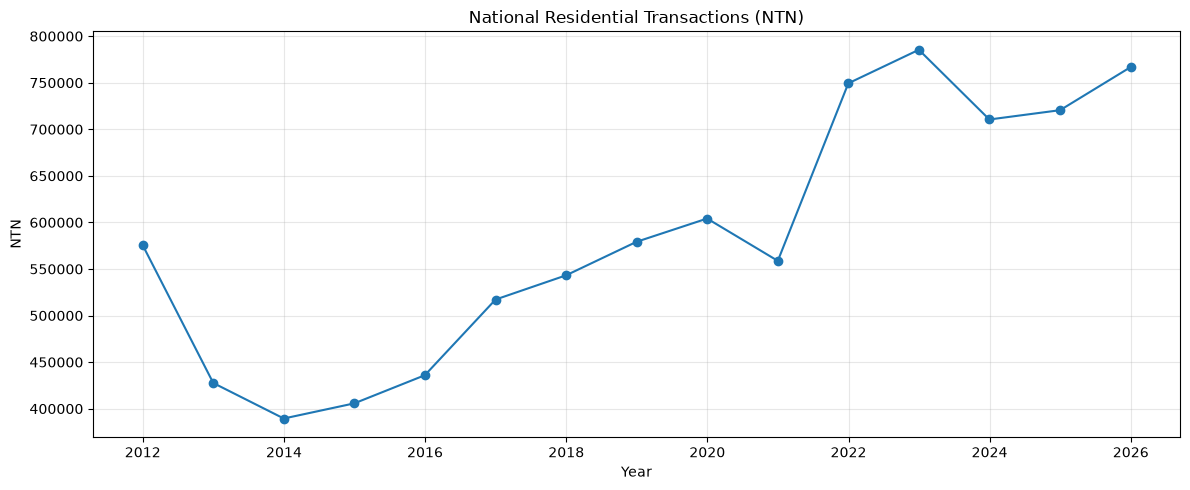

In [186]:
fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(
    national_ntn["reference_date"],
    national_ntn["NTN"],
    marker="o",
)

ax.set_title("National Residential Transactions (NTN)")
ax.set_xlabel("Year")
ax.set_ylabel("NTN")
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [188]:
regional_ntn = (
    transactions_df
    .groupby("Regione")["NTN"]
    .sum()
    .sort_values(ascending=False)
)

regional_ntn

Regione
Lombardia                 1846366.65
Lazio                      903513.38
Piemonte                   791481.58
Veneto                     782417.85
Emilia-Romagna             769349.42
Toscana                    591252.70
Sicilia                    581042.01
Campania                   520739.17
Puglia                     517933.57
Liguria                    320345.76
Sardegna                   207247.10
Marche                     197301.71
Calabria                   192757.14
Friuli- Venezia Giulia     127428.93
Umbria                     120030.26
Abruzzo                    102030.34
Abruzzo                     77810.83
Basilicata                  54196.97
Molise                      38276.67
Valle d'Aosta               27966.54
Name: NTN, dtype: float64

In [189]:
regional_ntn_share = (
    regional_ntn
    / regional_ntn.sum()
    * 100
)

regional_ntn_share

Regione
Lombardia                 21.054439
Lazio                     10.302920
Piemonte                   9.025402
Veneto                     8.922047
Emilia-Romagna             8.773025
Toscana                    6.742157
Sicilia                    6.625723
Campania                   5.938079
Puglia                     5.906086
Liguria                    3.652958
Sardegna                   2.363275
Marche                     2.249866
Calabria                   2.198043
Friuli- Venezia Giulia     1.453094
Umbria                     1.368726
Abruzzo                    1.163470
Abruzzo                    0.887290
Basilicata                 0.618017
Molise                     0.436476
Valle d'Aosta              0.318907
Name: NTN, dtype: float64

In [192]:
regional_time = (
    transactions_df
    .groupby(["reference_date", "Regione"])["NTN"]
    .sum()
    .reset_index()
)

regional_time.head()

,reference_date,Regione,NTN
0,2011-12-31,Abruzzo,12794.64
1,2011-12-31,Basilicata,3794.09
2,2011-12-31,Calabria,14234.84
3,2011-12-31,Campania,33362.92
4,2011-12-31,Emilia-Romagna,48554.64


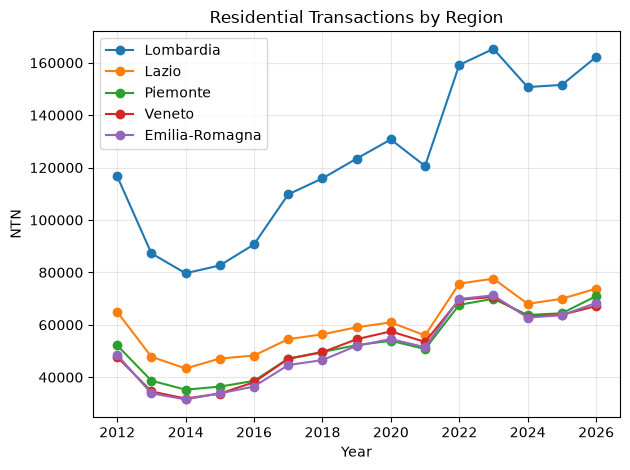

In [193]:
top_regions = (
    regional_ntn
    .head(5)
    .index
)

plot_data = regional_time[
    regional_time["Regione"].isin(top_regions)
]

for region in top_regions:
    subset = plot_data[
        plot_data["Regione"] == region
    ]

    plt.plot(
        subset["reference_date"],
        subset["NTN"],
        marker="o",
        label=region,
    )

plt.title("Residential Transactions by Region")
plt.xlabel("Year")
plt.ylabel("NTN")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### Property size composition

In [196]:
size_columns = [
    "NTN_0_50",
    "NTN_50_85",
    "NTN_85_115",
    "NTN_115_145",
    "NTN_145_PLUS",
]

size_totals = transactions_df[size_columns].sum()

size_share = (
    size_totals
    / size_totals.sum()
    * 100
)

size_share.sort_values(ascending=False)

NTN_50_85       31.239407
NTN_85_115      26.902468
NTN_145_PLUS    16.584149
NTN_115_145     15.922897
NTN_0_50         9.351080
dtype: float64

In [199]:
size_by_year = (
    transactions_df
    .groupby("reference_date")[size_columns]
    .sum()
)

size_share_by_year = (
    size_by_year
    .div(size_by_year.sum(axis=1), axis=0)
    * 100
)

size_share_by_year

,NTN_0_50,NTN_50_85,NTN_85_115,NTN_115_145,NTN_145_PLUS
reference_date,,,,,
2011-12-31,10.028873,33.676599,26.827028,15.451630,14.015869
2012-12-31,10.033776,33.021195,27.001427,15.542661,14.400941
2013-12-31,9.918146,32.577446,26.922066,15.806612,14.775730
2014-12-31,8.908325,31.438862,27.094289,17.205750,15.352774
2015-12-31,8.752341,30.792271,27.383605,17.170345,15.901439
2016-12-31,8.917262,31.134115,27.417483,16.162794,16.368345
2017-12-31,8.955150,31.063162,27.414412,16.008117,16.559159
2018-12-31,9.033942,30.810729,27.427732,16.050499,16.677098
2019-12-31,9.174586,30.728483,27.210887,15.969104,16.916940


In [200]:
size_share_by_year.sum(axis=1)

reference_date
2011-12-31    100.0
2012-12-31    100.0
2013-12-31    100.0
2014-12-31    100.0
2015-12-31    100.0
2016-12-31    100.0
2017-12-31    100.0
2018-12-31    100.0
2019-12-31    100.0
2020-12-31    100.0
2021-12-31    100.0
2022-12-31    100.0
2023-12-31    100.0
2024-12-31    100.0
2025-12-31    100.0
dtype: float64

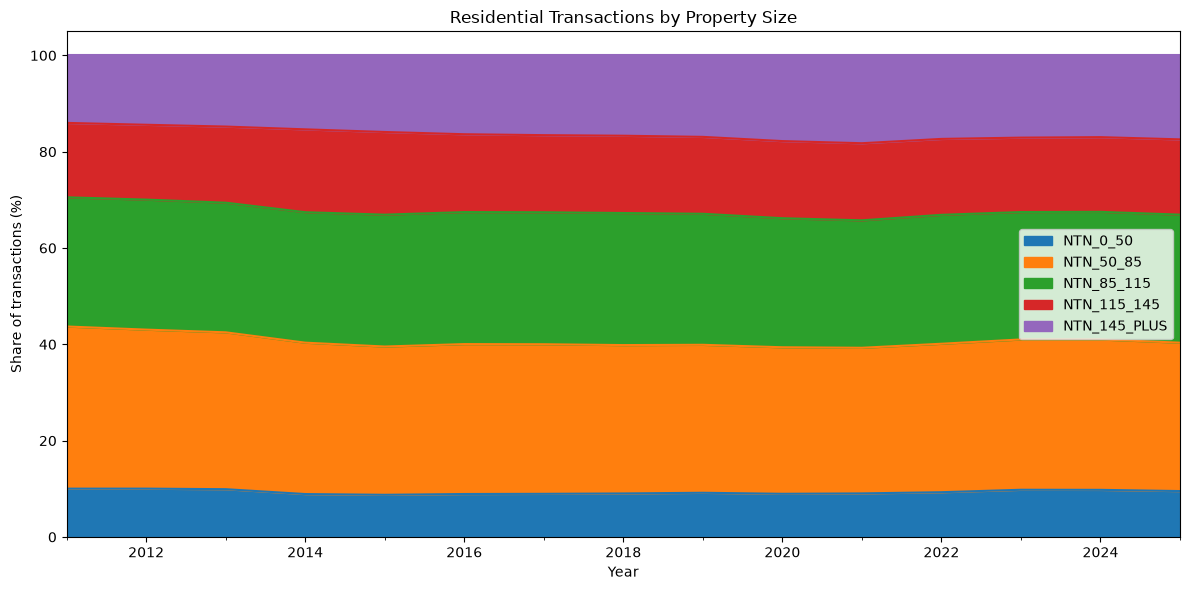

In [201]:
ax = size_share_by_year.plot(
    kind="area",
    stacked=True,
    figsize=(12, 6),
)

ax.set_title("Residential Transactions by Property Size")
ax.set_xlabel("Year")
ax.set_ylabel("Share of transactions (%)")

plt.tight_layout()
plt.show()

In [203]:
regional_size = (
    transactions_df
    .groupby("Regione")[size_columns]
    .sum()
)

regional_size_share = (
    regional_size
    .div(regional_size.sum(axis=1), axis=0)
    * 100
)

regional_size_share

,NTN_0_50,NTN_50_85,NTN_85_115,NTN_115_145,NTN_145_PLUS
Regione,,,,,
Abruzzo,10.351588,31.309599,24.449100,17.270520,16.619194
Abruzzo,9.623095,33.802158,25.097830,16.834816,14.642101
Basilicata,13.142580,29.172922,25.606708,18.583382,13.494408
Calabria,14.286698,29.267507,22.872818,17.681420,15.891557
Campania,10.327293,22.769447,27.920725,21.237792,17.744743
Emilia-Romagna,7.451918,31.677489,29.284686,14.802898,16.783009
Friuli- Venezia Giulia,6.474723,21.284256,24.204810,17.479320,30.556892
Lazio,9.740614,38.405818,26.752953,13.412833,11.687783
Liguria,13.287930,40.312062,26.780598,11.119033,8.500378


### Intensità del mercato

In [205]:
ntn_by_year = (
    transactions_df
    .groupby(["reference_date", "CodCom", "Comune"])["NTN"]
    .sum()
    .reset_index()
)

ntn_by_year.groupby("reference_date")["NTN"].describe()

,count,mean,std,min,25%,50%,75%,max
reference_date,,,,,,,,
2011-12-31,7715.0,74.633454,506.346639,0.0,7.67,20.500,57.0000,33531.73
2012-12-31,7715.0,55.420137,387.560664,0.0,6.00,15.340,42.1300,25649.71
2013-12-31,7698.0,50.590790,366.490317,0.0,5.33,13.790,37.3600,23762.97
2014-12-31,7665.0,52.931705,405.560128,0.0,5.19,13.970,38.1600,27104.24
2015-12-31,7661.0,56.902656,427.028996,0.0,5.50,14.750,40.8300,27355.95
2016-12-31,7645.0,67.650021,493.835457,0.0,6.17,16.500,47.8700,30214.28
2017-12-31,7624.0,71.247072,518.857507,0.0,6.50,17.500,51.0825,31164.67
2018-12-31,7603.0,76.181398,539.993257,0.0,7.00,18.550,55.1650,32111.56
2019-12-31,7564.0,79.874110,559.954656,0.0,7.15,19.880,58.3900,32787.12


In [206]:
ntn_by_year.groupby("reference_date")["NTN"].agg(
    mean="mean",
    median="median",
    std="std",
    min="min",
    max="max",
)

,mean,median,std,min,max
reference_date,,,,,
2011-12-31,74.633454,20.500,506.346639,0.0,33531.73
2012-12-31,55.420137,15.340,387.560664,0.0,25649.71
2013-12-31,50.590790,13.790,366.490317,0.0,23762.97
2014-12-31,52.931705,13.970,405.560128,0.0,27104.24
2015-12-31,56.902656,14.750,427.028996,0.0,27355.95
2016-12-31,67.650021,16.500,493.835457,0.0,30214.28
2017-12-31,71.247072,17.500,518.857507,0.0,31164.67
2018-12-31,76.181398,18.550,539.993257,0.0,32111.56
2019-12-31,79.874110,19.880,559.954656,0.0,32787.12


In [207]:
top_municipalities = (
    transactions_df
    .groupby(["CodCom", "Comune"])["NTN"]
    .sum()
    .sort_values(ascending=False)
    .head(20)
)

top_municipalities

CodCom  Comune            
H501    ROMA                  479019.06
F205    MILANO                330344.97
L219    TORINO                190709.55
D969    GENOVA                107042.08
F839    NAPOLI                105235.79
G273    PALERMO                80237.88
A944    BOLOGNA                80003.91
D612    FIRENZE                69065.75
A662    BARI                   51347.74
L736    VENEZIA                46323.84
L781    VERONA                 45699.67
C351    CATANIA                43961.98
G224    PADOVA                 42396.24
G337    PARMA                  39159.22
B157    BRESCIA                35675.65
H199    RAVENNA                33534.98
F257    MODENA                 30789.28
H223    REGGIO NELL`EMILIA     29845.26
F158    MESSINA                29691.51
E625    LIVORNO                27610.70
Name: NTN, dtype: float64

In [208]:
top_by_year = (
    transactions_df
    .groupby(["reference_date", "CodCom", "Comune"])["NTN"]
    .sum()
    .reset_index()
)

top_by_year.sort_values(
    ["reference_date", "NTN"],
    ascending=[True, False],
).groupby("reference_date").head(10)

,reference_date,CodCom,Comune,NTN
5688,2011-12-31,H501,ROMA,33531.73
3915,2011-12-31,F205,MILANO,19155.00
6940,2011-12-31,L219,TORINO,12013.27
2992,2011-12-31,D969,GENOVA,7003.37
4409,2011-12-31,F839,NAPOLI,6624.00
...,...,...,...,...
111311,2025-12-31,G273,PALERMO,7140.41
107414,2025-12-31,A944,BOLOGNA,6089.18
109336,2025-12-31,D612,FIRENZE,4643.31
107213,2025-12-31,A662,BARI,4243.15


In [209]:
municipality_totals = (
    transactions_df
    .groupby(["CodCom", "Comune"])["NTN"]
    .sum()
    .sort_values(ascending=False)
)

total_ntn = municipality_totals.sum()

concentration = pd.DataFrame({
    "Top_10": [
        municipality_totals.head(10).sum() / total_ntn * 100
    ],
    "Top_20": [
        municipality_totals.head(20).sum() / total_ntn * 100
    ],
    "Top_50": [
        municipality_totals.head(50).sum() / total_ntn * 100
    ],
})

concentration

,Top_10,Top_20,Top_50
0,17.553254,21.639746,28.30093


In [210]:
def top_share(group, n):
    values = group.sort_values(ascending=False)
    return values.head(n).sum() / values.sum() * 100


concentration_by_year = (
    transactions_df
    .groupby("reference_date")["NTN"]
    .apply(
        lambda x: pd.Series({
            "Top_10": top_share(x, 10),
            "Top_20": top_share(x, 20),
            "Top_50": top_share(x, 50),
        })
    )
    .unstack()
)

concentration_by_year

,Top_10,Top_20,Top_50
reference_date,,,
2011-12-31,17.158987,21.094507,27.898635
2012-12-31,17.845333,21.640641,28.200364
2013-12-31,18.652752,22.491124,29.074341
2014-12-31,19.474520,23.478861,30.221853
2015-12-31,19.398056,23.484148,30.341642
2016-12-31,19.132009,23.373123,30.227471
2017-12-31,19.136207,23.387651,30.164887
2018-12-31,18.756241,23.095208,29.897204
2019-12-31,18.418326,22.764404,29.716780


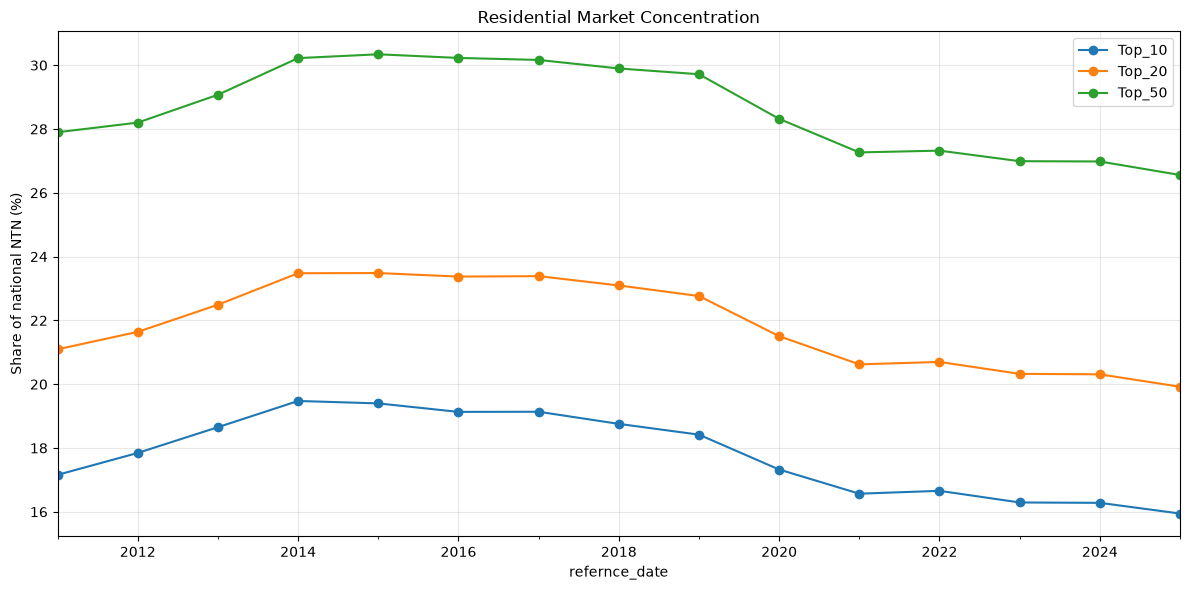

In [211]:
ax = concentration_by_year.plot(
    figsize=(12, 6),
    marker="o",
)

ax.set_title("Residential Market Concentration")
ax.set_xlabel("refernce_date")
ax.set_ylabel("Share of national NTN (%)")
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()